# Сравнение ResNet, ViT и Swin с погрешностями

In [ ]:
import os
import numpy as np
import pandas as pd
import glob

import torch
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from scipy.optimize import curve_fit

# -------------------------------
# 1. Configuration
# -------------------------------
IMAGENET_DIR = "../imagenet"
SAVE_PATH = "zero/"
FIG_PATH = os.path.join(SAVE_PATH, "compare")
TABLE_PATH = os.path.join(SAVE_PATH, "tables")
SPECTRA_PATH = os.path.join(SAVE_PATH, "spectra_npz")

BATCH_SIZE = 32
NUM_WORKERS = 4
MAX_BATCHES = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

LOW_THRESH = 0.15
HIGH_THRESH = 0.50

# Если нужен глобальный масштаб как у layer1 ResNet при новой методике Rmax=min(H,W)/2:
# для входа 224x224 у ResNet layer1 обычно 56x56, значит Rmax=28 и длина кривой 29.
RESNET_LAYER1_REF_LEN = 29

os.makedirs(SAVE_PATH, exist_ok=True)
os.makedirs(FIG_PATH, exist_ok=True)
os.makedirs(TABLE_PATH, exist_ok=True)
os.makedirs(SPECTRA_PATH, exist_ok=True)

print("DEVICE:", DEVICE)
print("SAVE_PATH:", SAVE_PATH)

DEVICE: cpu
SAVE_PATH: zero/


## Сохранённые спектры открыть

In [63]:
def load_spectra_npz(path):
    data = np.load(path, allow_pickle=True)
    layers = list(data["layers"])
    stats = {}
    for i, layer in enumerate(layers):
        stats[layer] = {
            "curves_mean": data[f"curves_mean_{i}"],
            "curves_energy": data[f"curves_energy_{i}"],
            "mean": data[f"mean_{i}"],
            "std": data[f"std_{i}"],
            "energy_mean": data[f"energy_mean_{i}"],
            "energy_std": data[f"energy_std_{i}"],
            "rho": data[f"rho_{i}"],
            "resolution": tuple(data[f"resolution_{i}"].tolist()),
            "n": int(data[f"n_{i}"])
        }
    return stats


# -------------------------------
# 7. Metrics and LaTeX tables
# -------------------------------
def compute_metrics_for_layer(energy_curves, rho, freq_scale=1.0, low_thresh=LOW_THRESH, high_thresh=HIGH_THRESH):
    rows = []
    x = rho * freq_scale
    for curve in energy_curves:
        curve = curve / max(curve.sum(), 1e-12)
        centroid = float(np.sum(x * curve))
        low_frac = float(curve[x < low_thresh].sum())
        high_frac = float(curve[x > high_thresh].sum())
        rows.append({
            "centroid": centroid,
            "low_frac": low_frac,
            "high_frac": high_frac
        })
    return pd.DataFrame(rows)


def summarize_layer_metrics(df):
    return {
        "centroid_mean": df["centroid"].mean(),
        "centroid_std": df["centroid"].std(ddof=1),
        "low_frac_mean": df["low_frac"].mean(),
        "low_frac_std": df["low_frac"].std(ddof=1),
        "high_frac_mean": df["high_frac"].mean(),
        "high_frac_std": df["high_frac"].std(ddof=1),
        "n": len(df)
    }


def compute_metrics_table(stats, selected_layers, ref_layer=None, ref_len=None, architecture=""):
    if ref_len is None:
        if ref_layer is None:
            ref_layer = selected_layers[0]
        ref_len = len(stats[ref_layer]["rho"])

    rows = []
    for pos, layer in selected_layers.items():
        d = stats[layer]
        freq_scale = len(d["rho"]) / ref_len
        df = compute_metrics_for_layer(
            d["curves_energy"],
            d["rho"],
            freq_scale=freq_scale,
            low_thresh=LOW_THRESH,
            high_thresh=HIGH_THRESH
        )
        s = summarize_layer_metrics(df)
        rows.append({
            "architecture": architecture,
            "position": pos,
            "layer": layer,
            "resolution": str(d["resolution"]),
            "freq_scale": freq_scale,
            **s
        })
    return pd.DataFrame(rows)


def fmt_pm(mean, std, digits=3, percent=False):
    if percent:
        mean = mean * 100
        std = std * 100
    return f"{mean:.{digits}f} $\\pm$ {std:.{digits}f}"


def make_latex_ready_table(metrics_df, model_name):
    rows = []
    for _, r in metrics_df.iterrows():
        rows.append({
            "Модель": model_name,
            "Уровень": r["position"],
            "Слой/блок": r["layer"],
            "Центроид": fmt_pm(r["centroid_mean"], r["centroid_std"], digits=3),
            "LowFrac, \\%": fmt_pm(r["low_frac_mean"], r["low_frac_std"], digits=3, percent=True),
            "HighFrac, \\%": fmt_pm(r["high_frac_mean"], r["high_frac_std"], digits=3, percent=True),
        })
    return pd.DataFrame(rows)


def save_metrics_tables(metrics_df, model_name, prefix):
    csv_path = os.path.join(TABLE_PATH, f"{prefix}_metrics_long.csv")
    tex_path = os.path.join(TABLE_PATH, f"{prefix}_metrics_latex.tex")
    pretty_path = os.path.join(TABLE_PATH, f"{prefix}_metrics_latex_ready.csv")

    latex_df = make_latex_ready_table(metrics_df, model_name)
    metrics_df.to_csv(csv_path, index=False)
    latex_df.to_csv(pretty_path, index=False)

    with open(tex_path, "w", encoding="utf-8") as f:
        f.write(latex_df.to_latex(index=False, escape=False))

    print("saved:", csv_path)
    print("saved:", pretty_path)
    print("saved:", tex_path)
    return latex_df


# Загружаем npz из трёх архитектурных ноутбуков.
resnet_files = {
    "ResNet_18": "resnet18_all_layers.npz",
    "ResNet_34": "resnet34_all_layers.npz",
    "ResNet_50": "resnet50_all_layers.npz",
    "ResNet_101": "resnet101_all_layers.npz",
}
vit_files = {
    "ViT_Tiny": "vit_t_16_all_layers.npz",
    "ViT_Small": "vit_s_16_all_layers.npz",
    "ViT_Base": "vit_b_16_all_layers.npz",
    "ViT_Large": "vit_l_16_all_layers.npz",
}
swin_files = {
    "Swin_Tiny": "swin_tiny_all_layers.npz",
    "Swin_Small": "swin_small_all_layers.npz",
    "Swin_Base": "swin_base_all_layers.npz",
    "Swin_Large": "swin_large_all_layers.npz",
}

all_stats = {}
for d in [swin_files, vit_files, resnet_files]:
    for key, filename in d.items():
        path = os.path.join(SPECTRA_PATH, filename)
        if os.path.exists(path):
            all_stats[key] = load_spectra_npz(path)
        else:
            print("Нет файла:", path)

print("loaded models:", list(all_stats.keys()))

loaded models: ['Swin_Tiny', 'Swin_Small', 'Swin_Base', 'Swin_Large', 'ViT_Tiny', 'ViT_Small', 'ViT_Base', 'ViT_Large', 'ResNet_18', 'ResNet_34', 'ResNet_50', 'ResNet_101']


## Функции графиков и метрик

In [58]:
markers = {
    "18": "s", "34": "o", "50": ">", "101": "d",
    "Tiny": "s", "Small": "o", "Base": ">", "Large": "d",
}

def model_family(key):
    if key.startswith("ResNet"):
        return "ResNet"
    if key.startswith("ViT"):
        return "ViT"
    if key.startswith("Swin"):
        return "Swin"
    return "Other"

def model_marker(key):
    for m in ["Tiny", "Small", "Base", "Large", "18", "34", "50", "101"]:
        if m in key:
            return markers[m]
    return "o"

def family_color(key):
    cmap = plt.get_cmap('tab20c')
    return cmap(key)

def selected_layer_by_block(stats, block):
    layers = list(stats.keys())
    num = len(layers)
    if block == "начального":
        return layers[0]
    if block == "среднего":
        return layers[num // 2]
    if block == "последнего":
        return layers[-1]
    raise ValueError("block должен быть: начального, среднего или последнего")


def curve_for_plot(d):
    curve = d["mean"].copy()
    std = d["std"].copy()
    m = max(curve.max(), 1e-12)
    return curve / m, std / m

def plot_spectra_compare_in_layer(models_dict, block, save_path=None, shape = None):
    plt.style.use("seaborn-v0_8")
    plt.figure(figsize=(10, 8))

    # Глобальный ref_res берём как максимальную длину кривой среди всех моделей.
    # Это масштаб самого большого пространственного разрешения.
    ref_res = max(len(stats[list(stats.keys())[0]]["mean"]) for stats in models_dict.values())

    for color, (key, stats) in enumerate(models_dict.items()):
        layer = selected_layer_by_block(stats, block)
        curve, std = curve_for_plot(stats[layer])
        L = len(curve)
        x = np.arange(L) / max(1, L - 1)
        scale = L / ref_res
        x_mapped = x * scale

        plt.plot(x_mapped, curve,
                 label=f"{key}-{layer}",
                 color=family_color(color),
                 linewidth=3,
                 marker=model_marker(key),
                 markevery=max(1, L//8))
        # plt.fill_between(x_mapped, np.maximum(curve-std, 0), curve+std, color=family_color(key), alpha=0.1)
        step = max(1, L // 8)
        # plt.errorbar(x_mapped[::step], curve[::step], yerr=std[::step],
        #              fmt="none", color=family_color(color), elinewidth=1.2, capsize=3, alpha=0.8)

    line_blue = mlines.Line2D([], [], color='blue', label='Swin', linewidth=3)
    line_red = mlines.Line2D([], [], color='red', label='ViT', linewidth=3)
    line_green = mlines.Line2D([], [], color='green', label='ResNet', linewidth=3)
    point_s = mlines.Line2D([], [], marker='s', linestyle='None', markersize=10, label='Tiny / 18')
    point_o = mlines.Line2D([], [], marker='o', linestyle='None', markersize=10, label='Small / 34')
    point_t = mlines.Line2D([], [], marker='>', linestyle='None', markersize=10, label='Base / 50')
    point_d = mlines.Line2D([], [], marker='d', linestyle='None', markersize=10, label='Large / 101')

    plt.title(f"Спектральная энергия {block} слоя", fontsize=25, fontweight='bold', pad=20)
    plt.xlabel("Нормализованный частотный радиус, \nприведённый к масштабу layer1", fontsize=25, labelpad=20)
    plt.ylabel("Нормализованная спектральная энергия", fontsize=25, labelpad=20)
    plt.grid(True)
    plt.legend(handles=[point_s, point_o, point_t, point_d, line_blue, line_red, line_green],
               title="Обозначения", loc='upper right', ncol=2, framealpha=0.8, fontsize=18)
    plt.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

## Отрисовывание графиков сравнения архитектур

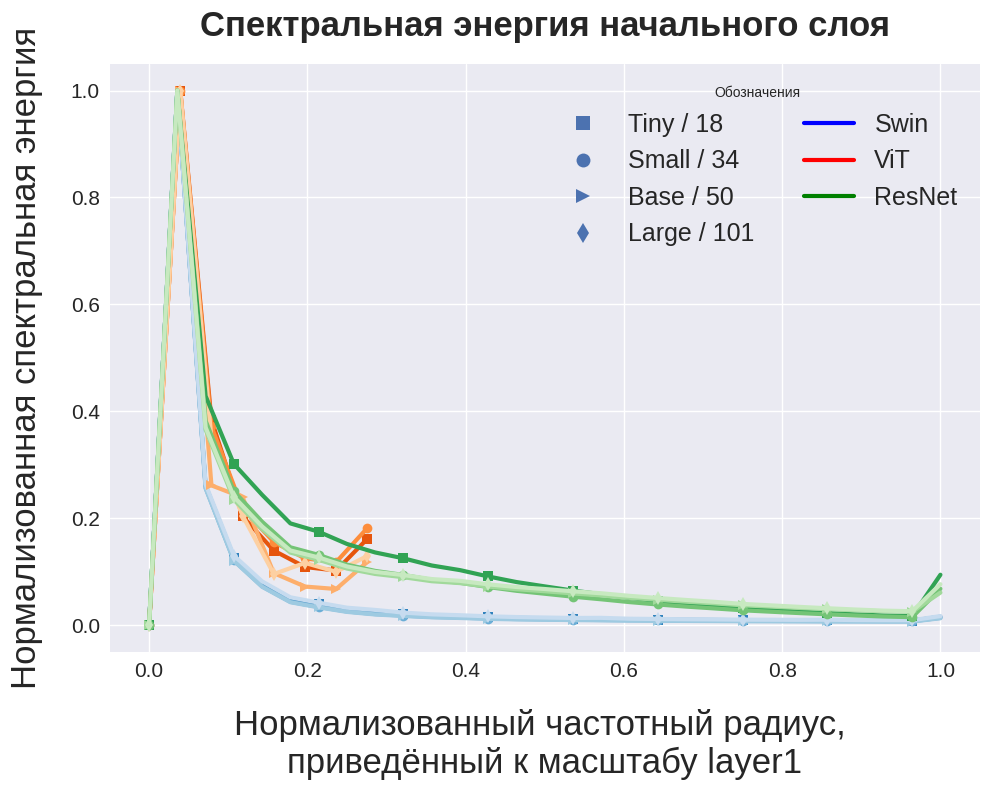

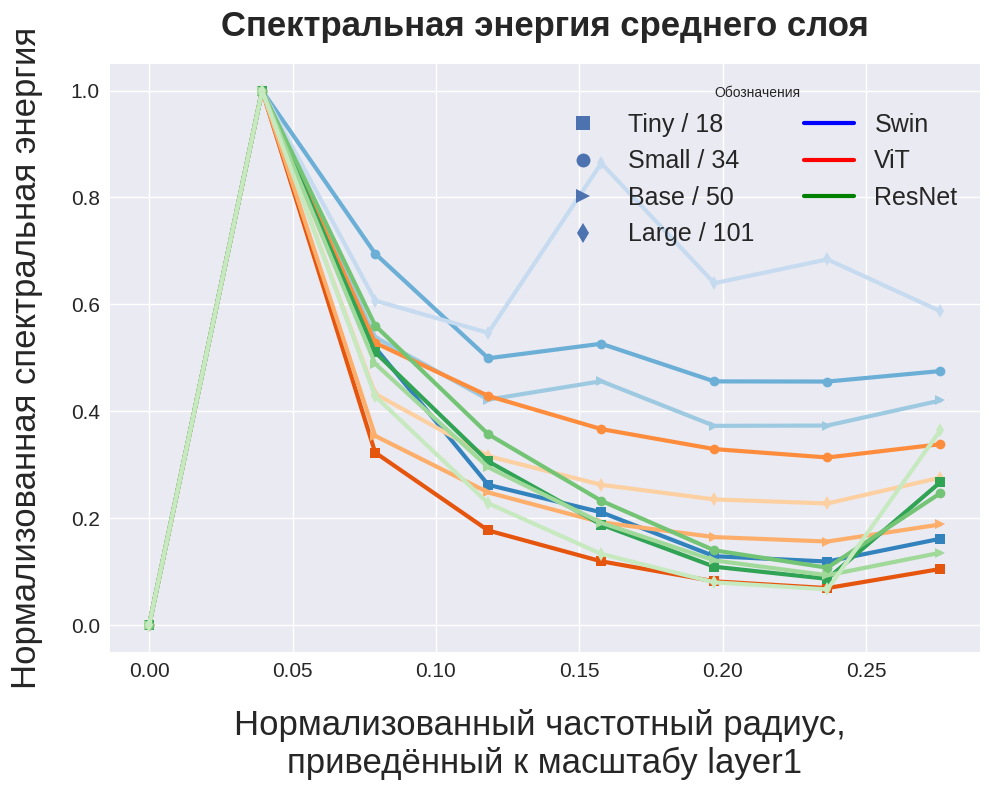

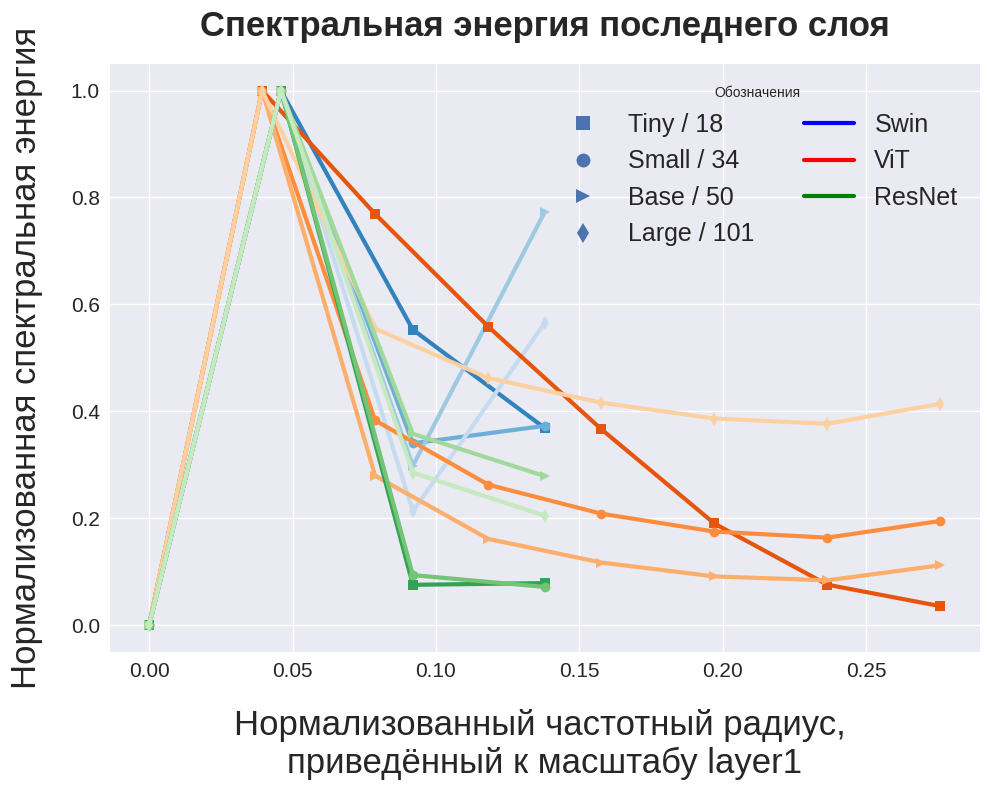

In [59]:
plot_spectra_compare_in_layer(all_stats, "начального", os.path.join(FIG_PATH, "compare_begin_block.png"))
plot_spectra_compare_in_layer(all_stats, "среднего", os.path.join(FIG_PATH, "compare_middle_block.png"))
plot_spectra_compare_in_layer(all_stats, "последнего", os.path.join(FIG_PATH, "compare_last_block.png"))

## Выведение и сохранение общей таблицы метрик

In [60]:
# Таблица только для начального, среднего и последнего слоя/блока.
all_metrics = []
ref_res = max(len(stats[list(stats.keys())[0]]["rho"]) for stats in all_stats.values())

for key, stats in all_stats.items():
    layers = list(stats.keys())
    selected = {
        "Начальные": layers[0],
        "Средние": layers[len(layers)//2],
        "Глубокие": layers[-1],
    }
    df = compute_metrics_table(stats, selected, ref_len=ref_res, architecture=key)
    all_metrics.append(df)

metrics_all = pd.concat(all_metrics, ignore_index=True)
metrics_all.to_csv(os.path.join(TABLE_PATH, "all_architectures_metrics_long.csv"), index=False)

def make_compact_metric_table(metrics_all, metric_prefix, percent=False):
    rows = []
    for arch, g in metrics_all.groupby("architecture"):
        row = {"Архитектура": arch}
        for _, r in g.iterrows():
            mean = r[f"{metric_prefix}_mean"]
            std = r[f"{metric_prefix}_std"]
            row[r["position"]] = fmt_pm(mean, std, digits=3, percent=percent)
        rows.append(row)
    return pd.DataFrame(rows)

centroid_table = make_compact_metric_table(metrics_all, "centroid", percent=False)
low_table = make_compact_metric_table(metrics_all, "low_frac", percent=True)
high_table = make_compact_metric_table(metrics_all, "high_frac", percent=True)

for name, df in [("centroid", centroid_table), ("low_frac", low_table), ("high_frac", high_table)]:
    df.to_csv(os.path.join(TABLE_PATH, f"all_architectures_{name}_latex_ready.csv"), index=False)
    with open(os.path.join(TABLE_PATH, f"all_architectures_{name}_latex.tex"), "w", encoding="utf-8") as f:
        f.write(df.to_latex(index=False, escape=False))
    display(df)

,Архитектура,Начальные,Средние,Глубокие
0,ResNet_101,0.484 $\pm$ 0.032,0.114 $\pm$ 0.005,0.067 $\pm$ 0.004
1,ResNet_18,0.431 $\pm$ 0.034,0.119 $\pm$ 0.006,0.055 $\pm$ 0.002
2,ResNet_34,0.436 $\pm$ 0.036,0.123 $\pm$ 0.006,0.056 $\pm$ 0.002
3,ResNet_50,0.480 $\pm$ 0.034,0.120 $\pm$ 0.006,0.071 $\pm$ 0.004
4,Swin_Base,0.340 $\pm$ 0.090,0.154 $\pm$ 0.004,0.078 $\pm$ 0.010
5,Swin_Large,0.383 $\pm$ 0.079,0.167 $\pm$ 0.004,0.073 $\pm$ 0.007
6,Swin_Small,0.348 $\pm$ 0.091,0.156 $\pm$ 0.005,0.072 $\pm$ 0.007
7,Swin_Tiny,0.369 $\pm$ 0.086,0.124 $\pm$ 0.007,0.075 $\pm$ 0.006
8,ViT_Base,0.112 $\pm$ 0.008,0.133 $\pm$ 0.012,0.117 $\pm$ 0.013
9,ViT_Large,0.121 $\pm$ 0.007,0.143 $\pm$ 0.007,0.154 $\pm$ 0.007


,Архитектура,Начальные,Средние,Глубокие
0,ResNet_101,16.051 $\pm$ 4.066,67.072 $\pm$ 3.017,100.000 $\pm$ 0.000
1,ResNet_18,17.832 $\pm$ 4.562,64.038 $\pm$ 3.533,100.000 $\pm$ 0.000
2,ResNet_34,19.230 $\pm$ 4.878,60.876 $\pm$ 3.543,100.000 $\pm$ 0.000
3,ResNet_50,16.692 $\pm$ 4.354,62.548 $\pm$ 3.640,100.000 $\pm$ 0.000
4,Swin_Base,44.194 $\pm$ 14.614,38.511 $\pm$ 3.146,100.000 $\pm$ 0.000
5,Swin_Large,36.661 $\pm$ 12.507,28.543 $\pm$ 3.607,100.000 $\pm$ 0.000
6,Swin_Small,43.009 $\pm$ 14.656,37.743 $\pm$ 3.771,100.000 $\pm$ 0.000
7,Swin_Tiny,39.189 $\pm$ 13.636,59.380 $\pm$ 4.247,100.000 $\pm$ 0.000
8,ViT_Base,68.402 $\pm$ 4.884,52.567 $\pm$ 7.525,62.402 $\pm$ 7.364
9,ViT_Large,62.201 $\pm$ 4.225,46.683 $\pm$ 4.687,39.819 $\pm$ 4.989


,Архитектура,Начальные,Средние,Глубокие
0,ResNet_101,46.414 $\pm$ 4.806,0.000 $\pm$ 0.000,0.000 $\pm$ 0.000
1,ResNet_18,36.460 $\pm$ 5.217,0.000 $\pm$ 0.000,0.000 $\pm$ 0.000
2,ResNet_34,38.300 $\pm$ 5.341,0.000 $\pm$ 0.000,0.000 $\pm$ 0.000
3,ResNet_50,45.691 $\pm$ 5.010,0.000 $\pm$ 0.000,0.000 $\pm$ 0.000
4,Swin_Base,30.167 $\pm$ 10.920,0.000 $\pm$ 0.000,0.000 $\pm$ 0.000
5,Swin_Large,35.137 $\pm$ 9.760,0.000 $\pm$ 0.000,0.000 $\pm$ 0.000
6,Swin_Small,31.248 $\pm$ 11.136,0.000 $\pm$ 0.000,0.000 $\pm$ 0.000
7,Swin_Tiny,33.549 $\pm$ 10.526,0.000 $\pm$ 0.000,0.000 $\pm$ 0.000
8,ViT_Base,0.000 $\pm$ 0.000,0.000 $\pm$ 0.000,0.000 $\pm$ 0.000
9,ViT_Large,0.000 $\pm$ 0.000,0.000 $\pm$ 0.000,0.000 $\pm$ 0.000


## Загрузка уже сохранённых таблиц

In [61]:
# Примеры:
# pd.read_csv(os.path.join(TABLE_PATH, "all_architectures_metrics_long.csv"))
# pd.read_csv(os.path.join(TABLE_PATH, "all_architectures_centroid_latex_ready.csv"))

## Расчет скорости сжатия спектрального центроида

In [ ]:
os.makedirs(TABLE_PATH, exist_ok=True)

npz_files = sorted(glob.glob("**/*_all_layers.npz", recursive=True))

def model_name(path):
    name = os.path.basename(path).replace("_all_layers.npz", "")
    name = name.replace("resnet", "ResNet_")
    name = name.replace("vit_t_16", "ViT_Tiny")
    name = name.replace("vit_s_16", "ViT_Small")
    name = name.replace("vit_b_16", "ViT_Base")
    name = name.replace("vit_l_16", "ViT_Large")
    name = name.replace("swin_tiny", "Swin_Tiny")
    name = name.replace("swin_small", "Swin_Small")
    name = name.replace("swin_base", "Swin_Base")
    name = name.replace("swin_large", "Swin_Large")
    return name


def exp_func(t, A0, beta):
    return A0 * np.exp(-beta * t)


def fit_beta(y):
    y = np.asarray(y, dtype=float)
    mask = np.isfinite(y) & (y > 0)

    if mask.sum() < 3:
        return np.nan

    t = np.linspace(0, 1, len(y))[mask]
    y = y[mask]

    try:
        params, _ = curve_fit(exp_func, t, y, p0=(y[0], 0.1), maxfev=10000)
        return params[1]
    except Exception:
        k, b = np.polyfit(t, np.log(y), 1)
        return -k


def get_centroids_from_npz(path, ref_len=RESNET_LAYER1_REF_LEN):
    data = np.load(path, allow_pickle=True)
    layers = data["layers"]
    n_layers = len(layers)

    n_images = min(data[f"curves_energy_{i}"].shape[0] for i in range(n_layers))
    centroids = []

    for i in range(n_layers):
        curves = data[f"curves_energy_{i}"][:n_images].astype(float)
        rho = data[f"rho_{i}"].astype(float)

        m = min(curves.shape[1], len(rho))
        curves = curves[:, :m]
        rho = rho[:m]

        curves = curves / np.maximum(curves.sum(axis=1, keepdims=True), 1e-12)

        x = rho * (len(rho) / ref_len)
        c = (curves * x[None, :]).sum(axis=1)

        centroids.append(c)

    return np.stack(centroids, axis=1), layers


rows = []
centroid_rows = []

for path in npz_files:
    name = model_name(path)
    centroids, layers = get_centroids_from_npz(path)

    betas = np.array([fit_beta(centroids[i]) for i in range(centroids.shape[0])])
    betas = betas[np.isfinite(betas)]

    rows.append({
        "model": name,
        "n_layers": centroids.shape[1],
        "n_images": centroids.shape[0],
        "lambda_mean": betas.mean(),
        "lambda_std": betas.std(ddof=1),
    })

    for j, layer in enumerate(layers):
        vals = centroids[:, j]
        centroid_rows.append({
            "model": name,
            "layer": str(layer),
            "layer_index": j,
            "centroid_mean": vals.mean(),
            "centroid_std": vals.std(ddof=1),
        })


lambda_df = pd.DataFrame(rows).sort_values("model")
centroid_df = pd.DataFrame(centroid_rows).sort_values(["model", "layer_index"])

lambda_df.to_csv(f"{TABLE_PATH}/lambda_all_layers.csv", index=False)
centroid_df.to_csv(f"{TABLE_PATH}/centroids_all_layers.csv", index=False)

lambda_df

,model,n_layers,n_images,lambda_mean,lambda_std
0,ResNet_101,4,10012,2.027698,0.084898
1,ResNet_18,4,10012,1.929765,0.109059
2,ResNet_34,4,10012,1.953519,0.114942
3,ResNet_50,4,10012,2.019092,0.097671
4,Swin_Base,24,10012,0.951125,0.352559
5,Swin_Large,24,10012,1.170556,0.311895
6,Swin_Small,24,10012,1.063092,0.364952
7,Swin_Tiny,12,10012,1.773551,0.425716
8,ViT_Base,12,10012,-0.078341,0.111609
9,ViT_Large,24,10012,-0.334117,0.077967


In [ ]:
def family_size(name):
    if name.startswith("ResNet_"):
        fam = "CNN"
        size = {
            "ResNet_18": "Tiny(18)",
            "ResNet_34": "Small(34)",
            "ResNet_50": "Base(50)",
            "ResNet_101": "Large(101)",
        }.get(name, name)

    elif name.startswith("ViT_"):
        fam = "ViT"
        size = {
            "ViT_Tiny": "Tiny(18)",
            "ViT_Small": "Small(34)",
            "ViT_Base": "Base(50)",
            "ViT_Large": "Large(101)",
        }.get(name, name)

    elif name.startswith("Swin_"):
        fam = "SWIN"
        size = {
            "Swin_Tiny": "Tiny(18)",
            "Swin_Small": "Small(34)",
            "Swin_Base": "Base(50)",
            "Swin_Large": "Large(101)",
        }.get(name, name)

    else:
        fam = "Other"
        size = name

    return fam, size


tmp = lambda_df.copy()
tmp[["Архитектура", "Размер"]] = tmp["model"].apply(lambda x: pd.Series(family_size(x)))
tmp["Значение"] = tmp.apply(
    lambda r: f'{r["lambda_mean"]:.3f} $\\pm$ {r["lambda_std"]:.3f}',
    axis=1
)

cols = ["Tiny(18)", "Small(34)", "Base(50)", "Large(101)"]
families = ["CNN", "ViT", "SWIN"]

table = []

for fam in families:
    row = {"Архитектура": fam}
    for col in cols:
        v = tmp[(tmp["Архитектура"] == fam) & (tmp["Размер"] == col)]["Значение"].values
        row[col] = v[0] if len(v) else ""
    table.append(row)

lambda_table = pd.DataFrame(table)

lambda_table.to_csv(f"{TABLE_PATH}/lambda_all_layers_table.csv", index=False)

with open(f"{TABLE_PATH}/lambda_all_layers_table.tex", "w", encoding="utf-8") as f:
    f.write(lambda_table.to_latex(index=False, escape=False))

lambda_table

,Архитектура,Tiny(18),Small(34),Base(50),Large(101)
0,CNN,1.930 $\pm$ 0.109,1.954 $\pm$ 0.115,2.019 $\pm$ 0.098,2.028 $\pm$ 0.085
1,ViT,-0.103 $\pm$ 0.132,-0.206 $\pm$ 0.115,-0.078 $\pm$ 0.112,-0.334 $\pm$ 0.078
2,SWIN,1.774 $\pm$ 0.426,1.063 $\pm$ 0.365,0.951 $\pm$ 0.353,1.171 $\pm$ 0.312
